In [87]:
import numpy as np
from PIL import Image

M = np.array(Image.open("anh.jpg").convert("L"), dtype=float)
print(M.shape)



(179, 192)


Mỗi hàng của ma trận đại diện cho một hàng điểm ảnh (pixel) nằm ngang, mỗi cột đại diện cho một cột điểm ảnh dọc. Giá trị số tại mỗi ô chính là cường độ sáng của pixel đó (dao động từ 0 đến 255)

In [88]:
mean_vec = np.mean(M, axis = 0)

print("Shape của ma trận M: ", M.shape)
print("Shape của vector trung bình: " , mean_vec.shape)

M_centered = M - mean_vec

print("Shape của ma trận sau khi trừ: ", M_centered.shape)

Shape của ma trận M:  (179, 192)
Shape của vector trung bình:  (192,)
Shape của ma trận sau khi trừ:  (179, 192)


Hai ma trận khác kích thước không thể trừ trực tiếp cho nhau. Ma trận M có kích thước (H x W), trong khi mean_vec chỉ là một mảng một chiều kích thước (W). Cơ chế Broadcasting của Python đã tự động hiểu ý và "nhân bản" vector mean_vec này thành H hàng. Nó tạo ra một ma trận ảo có cùng kích thước với M, sau đó mới thực hiện phép trừ từng phần tử.

In [89]:
def cosine_similarity(X, Y = None) :
    if Y is None :
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T


Hàm này thực hiện đo độ tương đồng giữa các hàng của bức ảnh bằng cách tính khoảng cách góc. Đầu tiên, thuật toán thực hiện chuẩn hóa ma trận theo hàng bằng cách chia cho chiều dài vector. Sau đó, phép nhân ma trận được sử dụng để tính tích vô hướng, trả về một ma trận tương đồng. Giá trị trong ma trận này càng gần 1 thì hai hàng càng giống nhau về cấu trúc phân bố pixel.

In [90]:
def search(query_idx, top_k=3):
    query_vector = M[query_idx:query_idx+1]
    sim_scores = cosine_similarity(query_vector, M)[0]
    
    top_indices = np.argsort(sim_scores)[::-1]
    top_indices = [i for i in top_indices if i != query_idx][:top_k]
    
    print(f"Truy vấn hàng {query_idx}:")
    for idx in top_indices:
        print(f"Hàng {idx} | Cosine: {sim_scores[idx]:.4f}")
    
    return top_indices

search(0, 3)

Truy vấn hàng 0:
Hàng 1 | Cosine: 0.9990
Hàng 2 | Cosine: 0.9983
Hàng 3 | Cosine: 0.9962


[np.int64(1), np.int64(2), np.int64(3)]

Hàm `search` thực hiện nhiệm vụ lấy ra vector của một hàng cụ thể (truy vấn) và so sánh nó với toàn bộ bức ảnh. Điểm Cosine được tính toán và sắp xếp theo thứ tự giảm dần để tìm ra `top_k` hàng (mặc định là 3) có độ tương đồng cao nhất với truy vấn ban đầu, kèm theo điểm số cụ thể.

In [91]:
sim_matrix = cosine_similarity(M)
np.fill_diagonal(sim_matrix, -1)

max_idx = np.unravel_index(np.argmax(sim_matrix), sim_matrix.shape)
print(f"Cặp giống nhất: Hàng {max_idx[0]} và Hàng {max_idx[1]} (Cosine: {sim_matrix[max_idx]:.4f})")

np.fill_diagonal(sim_matrix, 1)
min_idx = np.unravel_index(np.argmin(sim_matrix), sim_matrix.shape)
print(f"Cặp khác biệt nhất: Hàng {min_idx[0]} và Hàng {min_idx[1]} (Cosine: {sim_matrix[min_idx]:.4f})")

Cặp giống nhất: Hàng 19 và Hàng 20 (Cosine: 0.9996)
Cặp khác biệt nhất: Hàng 96 và Hàng 158 (Cosine: 0.5914)


Cặp giống nhau nhất (Hàng 19 và Hàng 20 - Cosine: 0.9996): Việc hai hàng nằm sát cạnh nhau đạt điểm tương đồng gần như tuyệt đối (tiệm cận 1) là khớp với trực giác. Vì các vùng không gian liền kề thường biểu diễn cùng một mảng chi tiết.
Cặp khác biệt nhất (Hàng 96 và Hàng 158 - Cosine: 0.5914): Hai hàng này nằm cách khá xa nhau về mặt tọa độ không gian trên bức ảnh (một hàng ở phần giữa, một hàng nằm về phía cuối). Điểm Cosine giảm xuống mức ~0.59 chứng tỏ cấu trúc vật thể, màu sắc hoặc điều kiện ánh sáng giữa hai khu vực này đã thay đổi rõ rệt, tạo ra hai dải vector có hướng lệch nhau nhiều nhất.

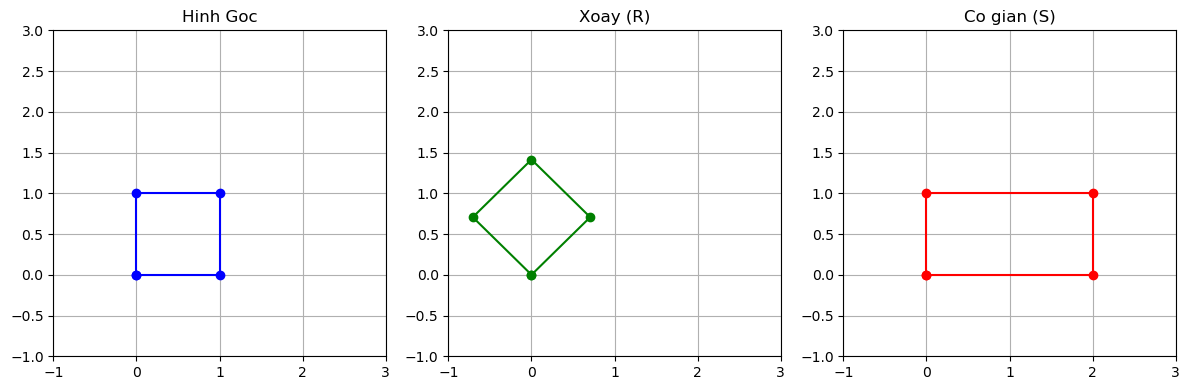

In [92]:
import numpy as np
import matplotlib.pyplot as plt

points = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
])

theta = np.pi / 4

R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

S = np.array([
    [2, 0],
    [0, 1]
])

points_rotated = R @ points
points_scaled = S @ points

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(points[0], points[1], 'b-o')
plt.title('Hinh Goc')
plt.xlim(-1, 3); plt.ylim(-1, 3)
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(points_rotated[0], points_rotated[1], 'g-o')
plt.title('Xoay (R)')
plt.xlim(-1, 3); plt.ylim(-1, 3)
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(points_scaled[0], points_scaled[1], 'r-o')
plt.title('Co gian (S)')
plt.xlim(-1, 3); plt.ylim(-1, 3)
plt.grid(True)

plt.tight_layout()
plt.show()


Phép biến đổi tuyến tính thực chất là phép nhân ma trận đối với tập hợp các vector tọa độ. 
* Ma trận $R(\theta)$ thực hiện phép nội suy góc, làm thay đổi hướng (xoay 45 độ) của vật thể trên không gian 2D mà không làm biến dạng tỷ lệ gốc.
* Ma trận $S$ thực hiện phép tinh chỉnh tỷ lệ (scaling), làm biến dạng kích thước của vật thể trên các trục tương ứng (ở ví dụ này là kéo giãn trục X lên gấp 2 lần).

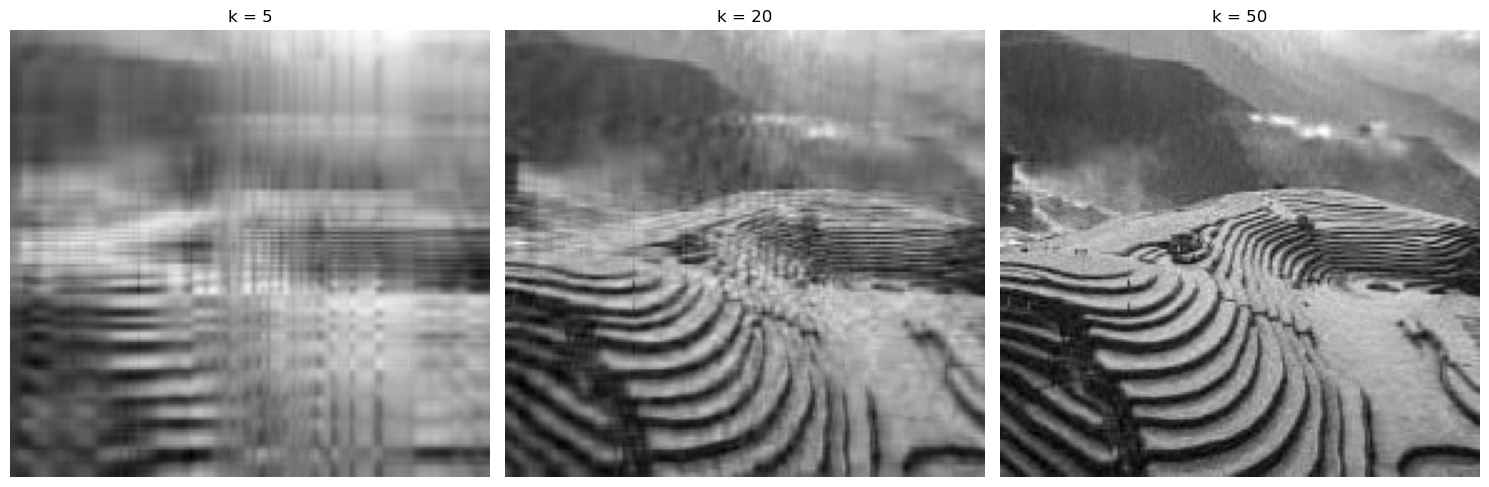

In [93]:
import numpy as np
import matplotlib.pyplot as plt

U, S, Vt = np.linalg.svd(M, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

k_values = [5, 20, 50]

plt.figure(figsize=(15, 5))
for i, k in enumerate(k_values):
    img_reconstructed = reconstruct(k)
    
    plt.subplot(1, 3, i + 1)
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title(f'k = {k}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Dựa vào kết quả tái tạo ảnh từ các điểm ma trận với 3 mức độ $k$ khác nhau, ta có thể thấy rõ sự tương quan trực tiếp giữa số lượng giá trị kỳ dị được giữ lại và chất lượng hình ảnh:

* **Với $k = 5$:** Ảnh bị mờ nhòe nặng, vỡ thành các khối pixel lớn (hiện tượng mosaic) và mất hoàn toàn chi tiết. Tại mức nén cực đại này, ma trận chỉ mới khôi phục được 5 thành phần cốt lõi nhất, đại diện cho cường độ sáng/tối chung của các mảng lớn.
* **Với $k = 20$:** Chất lượng ảnh được cải thiện đáng kể. Các đường nét, biên cạnh (edges) và hình khối của vật thể đã xuất hiện rõ ràng. Mắt người hoàn toàn có thể nhận diện được nội dung bức ảnh, dù bề mặt vẫn còn cảm giác nhiễu và thiếu độ sắc nét.
* **Với $k = 50$:** Bức ảnh tái tạo gần như hoàn hảo và rất khó để phân biệt độ sai lệch so với ảnh gốc bằng mắt thường. Các chi tiết nhỏ, vân bề mặt và độ tương phản đã được khôi phục trọn vẹn.

**Kết luận:** Thuật toán SVD chứng minh tính hiệu quả vượt trội trong việc nén dữ liệu. Nó hoạt động dựa trên nguyên lý: phần lớn thông tin cấu trúc quan trọng nhất của một bức ảnh chỉ nằm ở một vài giá trị kỳ dị lớn nhất (top $k$) trong ma trận $\Sigma$. Bằng cách mạnh tay cắt bỏ phần "đuôi" chứa các giá trị kỳ dị nhỏ (thường là nhiễu hoặc các chi tiết siêu vi không đáng kể), SVD giúp tiết kiệm một lượng khổng lồ không gian bộ nhớ trong khi vẫn bảo toàn được hình hài và đặc trưng của dữ liệu gốc.

--- ĐÁNH GIÁ TỈ LỆ NÉN VÀ SAI SỐ ---
k =  5 | Dung lượng bằng:  5.41% ảnh gốc | Sai số: 5568.16
k = 20 | Dung lượng bằng: 21.65% ảnh gốc | Sai số: 3079.50
k = 50 | Dung lượng bằng: 54.12% ảnh gốc | Sai số: 1277.12


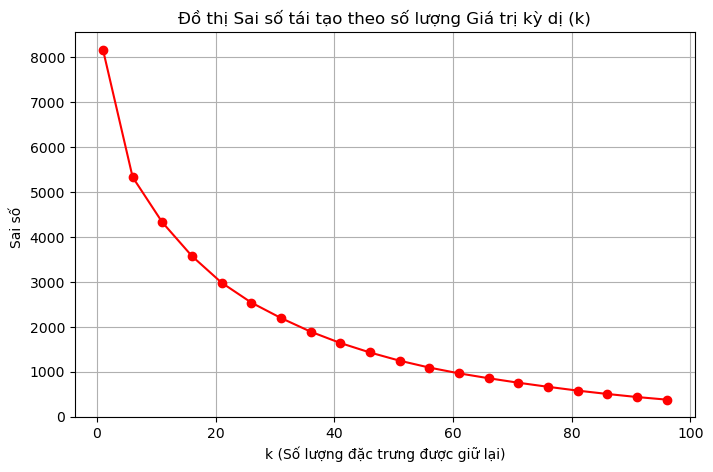

In [94]:
H, W = M.shape
original_size = H * W

print("--- ĐÁNH GIÁ TỈ LỆ NÉN VÀ SAI SỐ ---")
k_values = [5, 20, 50]

for k in k_values:
    compressed_size = k * (H + W + 1)
    compression_ratio = (compressed_size / original_size) * 100
    
    M_k = reconstruct(k)
    error = np.linalg.norm(M - M_k)
    
    print(f"k = {k:2d} | Dung lượng bằng: {compression_ratio:5.2f}% ảnh gốc | Sai số: {error:.2f}")


k_plot = range(1, 100, 5) 
errors_plot = [np.linalg.norm(M - reconstruct(k)) for k in k_plot]

plt.figure(figsize=(8, 5))
plt.plot(k_plot, errors_plot, marker='o', linestyle='-', color='red')
plt.title('Đồ thị Sai số tái tạo theo số lượng Giá trị kỳ dị (k)')
plt.xlabel('k (Số lượng đặc trưng được giữ lại)')
plt.ylabel('Sai số ')
plt.grid(True)
plt.show()

### 4. Nhận xét và Liên hệ với Machine Learning

**1. Điểm giới hạn (Threshold) của k:**
Dựa vào hình ảnh trực quan và đồ thị sai số, ta thấy hiện tượng "Khuỷu tay" (Elbow effect). Mức $k = 20$ có thể coi là ngưỡng tối thiểu để ảnh ở mức "chấp nhận được" (nhận diện được hình khối vật thể) với dung lượng cực thấp. Khi tăng lên $k = 50$, sai số giảm dần và đường cong bắt đầu đi ngang. Tại đây, chất lượng ảnh gần như bão hòa, việc cố gắng tăng $k$ lên thêm (như 100 hay 150) sẽ làm tốn bộ nhớ một cách vô ích vì mắt người không còn phân biệt được sự cải thiện.

**2. Liên hệ với Giảm chiều dữ liệu (Dimensionality Reduction) trong AI:**
* **Lọc Nhiễu (Noise Filtering):** Các giá trị kỳ dị nhỏ nằm ở cuối ma trận $\Sigma$ thường đại diện cho độ nhiễu của cảm biến camera hoặc các chi tiết nền không quan trọng. Việc loại bỏ chúng (giữ lại top $k$) không chỉ giúp nén ảnh mà còn đóng vai trò làm sạch dữ liệu.
* **Tối ưu hóa Huấn luyện (Training Optimization):** Trong Machine Learning (đặc biệt là thuật toán PCA có nền tảng toán học tương đương SVD), nếu ta đưa toàn bộ ảnh gốc có hàng ngàn pixel vào mạng Neural Network, mô hình sẽ rất chậm và dễ bị học vẹt (Overfitting). Kỹ thuật giảm chiều SVD giúp nén hàng ngàn pixel đó thành một vector $k$ chiều chứa "tinh hoa" cốt lõi nhất. Mô hình AI lúc này chỉ cần học trên $k$ đặc trưng này, giúp tăng tốc độ xử lý lên hàng trăm lần mà độ chính xác vẫn được đảm bảo.

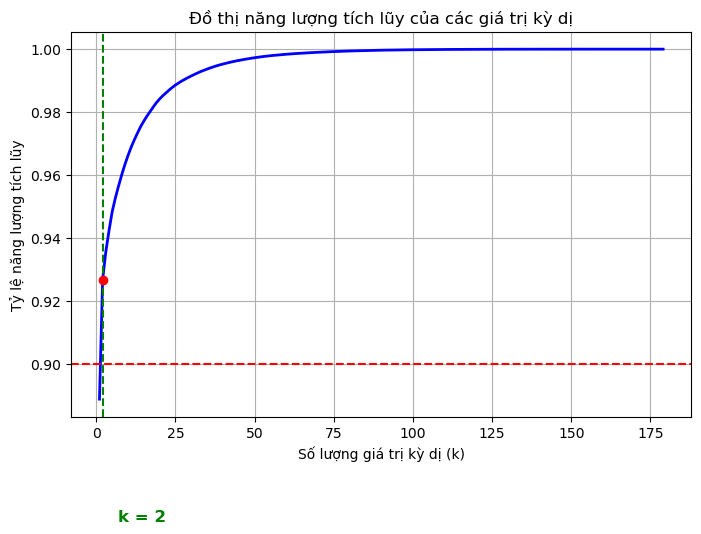

Giá trị k tối thiểu để giữ lại >= 90% thông tin là: 2


In [96]:
import numpy as np
import matplotlib.pyplot as plt

energy = S ** 2
cumulative_energy = np.cumsum(energy) / np.sum(energy)

k_90 = np.argmax(cumulative_energy >= 0.90) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_energy) + 1), cumulative_energy, 'b-', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--')
plt.axvline(x=k_90, color='g', linestyle='--')
plt.plot(k_90, cumulative_energy[k_90 - 1], 'ro')
plt.text(k_90 + 5, 0.85, f'k = {k_90}', color='green', fontsize=12, fontweight='bold')

plt.title('Đồ thị năng lượng tích lũy của các giá trị kỳ dị')
plt.xlabel('Số lượng giá trị kỳ dị (k)')
plt.ylabel('Tỷ lệ năng lượng tích lũy')
plt.grid(True)
plt.show()

print(f"Giá trị k tối thiểu để giữ lại >= 90% thông tin là: {k_90}")


Đồ thị năng lượng tích lũy cho thấy sự phân bố lượng thông tin (phương sai) của bức ảnh gốc tập trung chủ yếu ở một số ít các giá trị kỳ dị đầu tiên. 
* Đường cong có độ dốc cực lớn ở giai đoạn đầu, chứng tỏ các giá trị kỳ dị lớn nhất nắm giữ gần như toàn bộ cấu trúc không gian của ảnh.
* Bằng cách tính bình phương các giá trị kỳ dị ($\sigma_i^2$) để đại diện cho năng lượng, thuật toán đã tìm ra điểm cắt ngang tại ngưỡng $0.90$ (90%). 
* Kết quả cho thấy chỉ cần giữ lại $k$ giá trị kỳ dị (được đánh dấu trên đồ thị) là đã bảo toàn được 90% lượng thông tin hình ảnh gốc, phần còn lại (hàng trăm giá trị kỳ dị phía sau) chỉ đóng góp 10% thông tin nhưng lại chiếm quá nhiều dung lượng bộ nhớ. Điều này chứng minh SVD là một công cụ tối ưu hóa không gian lưu trữ cực kỳ mạnh mẽ.